<a href="https://colab.research.google.com/github/icosahedron31/Walmart-Sales/blob/main/ARIMA_SARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import wandb

In [3]:
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: tdola23 (tdola23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
import numpy as np
import pandas as pd
import torch
import json
import statsmodels

In [5]:
full_df = pd.read_csv("/content/drive/MyDrive/WalmartPrices/full.csv")

In [6]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

In [7]:
class DateToTimeIdx(BaseEstimator, TransformerMixin):

    def __init__(self, date_col='Date', time_idx_col='time_idx'):
        self.date_col = date_col
        self.time_idx_col = time_idx_col

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        dates = pd.to_datetime(X[self.date_col])
        self.min_date_ = dates.min()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X[self.date_col] = pd.to_datetime(X[self.date_col])

        delta_days = (X[self.date_col] - self.min_date_).dt.days
        X[self.time_idx_col] = (delta_days // 7).astype(int)

        return X


In [8]:
class PickColumns(BaseEstimator, TransformerMixin):

    def __init__(self, columns_to_pick=None):
        self.columns_to_pick = columns_to_pick

    def fit(self, X, y=None):

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X[self.columns_to_pick]

        return X


**Train/test split**

In [9]:
test_horizon = 35
full_dates = pd.to_datetime(full_df['Date']).sort_values().unique()
last_available_date = full_dates[-1]

# validation should end at last_available_date, and start 35 weeks before that
val_end_date = last_available_date
val_start_date = val_end_date - pd.Timedelta(weeks=test_horizon - 1)

print("New val range:", val_start_date, "to", val_end_date)

New val range: 2012-03-02 00:00:00 to 2012-10-26 00:00:00


In [10]:
full_df['Date'] = pd.to_datetime(full_df['Date'])

train_df = full_df[full_df['Date'] < val_start_date].copy()
val_df = full_df[full_df['Date'] >= val_start_date].copy()
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    421570 non-null  int64         
 1   Store         421570 non-null  int64         
 2   Dept          421570 non-null  int64         
 3   Date          421570 non-null  datetime64[ns]
 4   Weekly_Sales  421570 non-null  float64       
 5   IsHoliday_x   421570 non-null  bool          
 6   Week          421570 non-null  int64         
 7   Month         421570 non-null  int64         
 8   Year          421570 non-null  int64         
 9   Temperature   421570 non-null  float64       
 10  Fuel_Price    421570 non-null  float64       
 11  MarkDown1     150681 non-null  float64       
 12  MarkDown2     111248 non-null  float64       
 13  MarkDown3     137091 non-null  float64       
 14  MarkDown4     134967 non-null  float64       
 15  MarkDown5     151

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
pipe = Pipeline([

    ('Date_processor', DateToTimeIdx()),
    ('pick_columns', PickColumns(['Store', 'Dept', 'time_idx', 'Weekly_Sales', 'IsHoliday_x']))
])
train_df_t = pipe.fit_transform(train_df)
val_df_t = pipe.transform(val_df)
train_df_t.info()
val_df_t.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317928 entries, 0 to 421534
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         317928 non-null  int64  
 1   Dept          317928 non-null  int64  
 2   time_idx      317928 non-null  int64  
 3   Weekly_Sales  317928 non-null  float64
 4   IsHoliday_x   317928 non-null  bool   
dtypes: bool(1), float64(1), int64(3)
memory usage: 12.4 MB
<class 'pandas.core.frame.DataFrame'>
Index: 103642 entries, 108 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         103642 non-null  int64  
 1   Dept          103642 non-null  int64  
 2   time_idx      103642 non-null  int64  
 3   Weekly_Sales  103642 non-null  float64
 4   IsHoliday_x   103642 non-null  bool   
dtypes: bool(1), float64(1), int64(3)
memory usage: 4.1 MB


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


**Data visualisation**

length: 108
count      108.000000
mean     23173.964630
std      10406.663537
min      14537.370000
25%      16332.035000
50%      18988.700000
75%      23601.315000
max      57258.430000
Name: Weekly_Sales, dtype: float64


<Axes: title={'center': 'Store 1 Dept 1'}, xlabel='time_idx'>

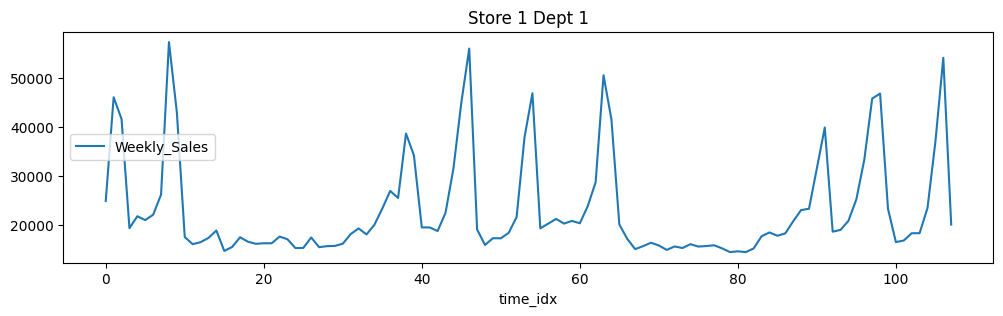

In [12]:
import pandas as pd

# grab one series
g = train_df_t[(train_df_t["Store"] == 1) & (train_df_t["Dept"] == 1)].sort_values("time_idx")
print("length:", len(g))
print(g["Weekly_Sales"].describe())

# quick look
g.plot(x="time_idx", y="Weekly_Sales", figsize=(12, 3), title="Store 1 Dept 1")

<Axes: title={'center': 'Store 1 Dept 1'}, xlabel='time_idx'>

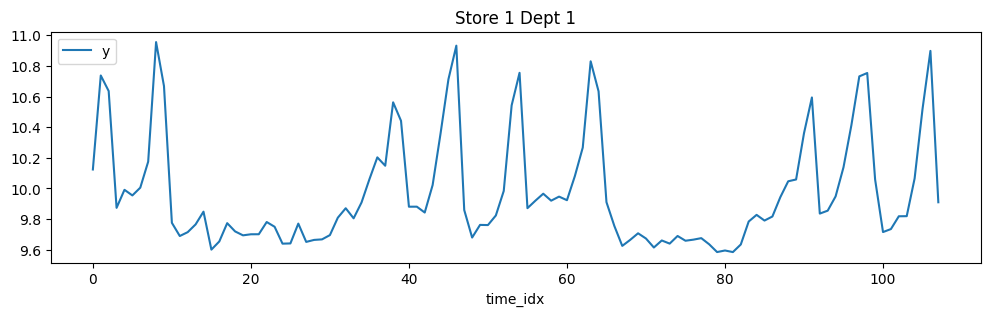

In [13]:
import numpy as np

g = g.copy()
g["y"] = np.log1p(g["Weekly_Sales"].clip(lower=0))   # variance-stabilize, handle negatives
g.plot(x="time_idx", y="y", figsize=(12, 3), title="Store 1 Dept 1")

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from statsmodels.tsa.arima.model import ARIMA

**Training**

In [22]:
import numpy as np, pandas as pd, time, pickle, warnings
from joblib import Parallel, delayed
from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import boxcox
from scipy.special import inv_boxcox
warnings.filterwarnings("ignore")

H = 35
HOLIDAY_WEIGHT = 5.0


CONFIGS = {

    "sarima_212_110_52":  dict(order=(2,1,2), seasonal_order=(1,1,0,52)),
    "sarima_111_111_52":  dict(order=(1,1,1), seasonal_order=(1,1,1,52)),
}

def fit_one(g, cfg):
    g = g.sort_values("time_idx")
    if len(g) < 60:
        return None
    y = g["Weekly_Sales"].clip(lower=1).values
    y_bc, lam = boxcox(y)
    tr = y_bc[:-H]
    val = g["Weekly_Sales"].values[-H:]
    is_hol = g["IsHoliday_x"].astype(bool).values[-H:]

    # a sane ceiling for this series: a few× its historical max
    cap = y.max() * 3.0

    try:
        res = ARIMA(tr, order=cfg["order"], seasonal_order=cfg["seasonal_order"]).fit()
        fc_bc = res.forecast(steps=H)
        fc = inv_boxcox(fc_bc, lam)
        # kill inf/nan, then clamp to a realistic range
        fc = np.nan_to_num(fc, nan=np.median(y), posinf=cap, neginf=0.0)
        fc = np.clip(fc, 0, cap)
    except Exception:
        fc = np.full(H, np.median(y))

    # final safety: if anything is still non-finite, fall back
    if not np.all(np.isfinite(fc)):
        fc = np.full(H, np.median(y))

    w = np.where(is_hol, HOLIDAY_WEIGHT, 1.0)
    return np.sum(w * np.abs(val - fc)), np.sum(w)


def run_config(cfg, verbose=True):
    groups = [g for _, g in train_df_t.groupby(["Store", "Dept"])]
    num = den = 0.0
    n_used = 0

    for i, g in enumerate(groups, 1):
        o = fit_one(g, cfg)
        if o is not None:
            num += o[0]
            den += o[1]
            n_used += 1
        if verbose and i % 100 == 0:
            print(f"  {i}/{len(groups)} groups  ({n_used} fitted)", flush=True)

    return num / den

In [ ]:
import wandb

for name, cfg in CONFIGS.items():
    run = wandb.init(project="walmart-sales-forecasting", group="arima/sarima",
                     name=name, config=cfg, reinit=True)
    t0 = time.time()
    overall = run_config(cfg)
    wandb.log({"overall_wmae": overall, "fit_seconds": time.time()-t0})
    print(f"{name}: WMAE={overall:.1f}")
    wandb.finish()

  100/3310 groups  (95 fitted)
  200/3310 groups  (184 fitted)
  300/3310 groups  (273 fitted)
  400/3310 groups  (363 fitted)
  500/3310 groups  (452 fitted)
  600/3310 groups  (545 fitted)
  700/3310 groups  (631 fitted)


In [ ]:
import os, joblib
print(os.cpu_count(), joblib.cpu_count())